In [1]:
import qiskit
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

print("Qiskit Version:", qiskit.__version__)
simulator = AerSimulator()

def apply_constant_oracle(qc, n, value):
    if value == 1:
        qc.x(n)

def apply_parity_oracle(qc, n):
    for q in range(n):
        qc.cx(q, n)

def apply_truth_table_oracle(qc, n, outputs):
    for x, fx in enumerate(outputs):
        if fx == 1:
            bits = format(x, f"0{n}b")
            for q, bit in enumerate(bits):
                if bit == "0": qc.x(q)
            qc.mcx(list(range(n)), n)
            for q, bit in enumerate(bits):
                if bit == "0": qc.x(q)

def deutsch_jozsa(n, oracle_type="constant", constant_value=0, outputs=None, shots=1024):
    qc = QuantumCircuit(n+1, n)
    qc.x(n)
    qc.h(range(n+1))
    if oracle_type == "constant": apply_constant_oracle(qc,n,constant_value)
    elif oracle_type == "parity": apply_parity_oracle(qc,n)
    elif oracle_type == "truth_table": apply_truth_table_oracle(qc,n,outputs)
    else: raise ValueError("Unknown oracle type")
    qc.h(range(n))
    qc.measure(range(n),range(n))
    counts = simulator.run(qc,shots=shots).result().get_counts()
    return qc, counts

def classify_result(counts,n):
    return "Constant" if counts.get("0"*n,0)==sum(counts.values()) else "Balanced"

Qiskit Version: 2.5.1


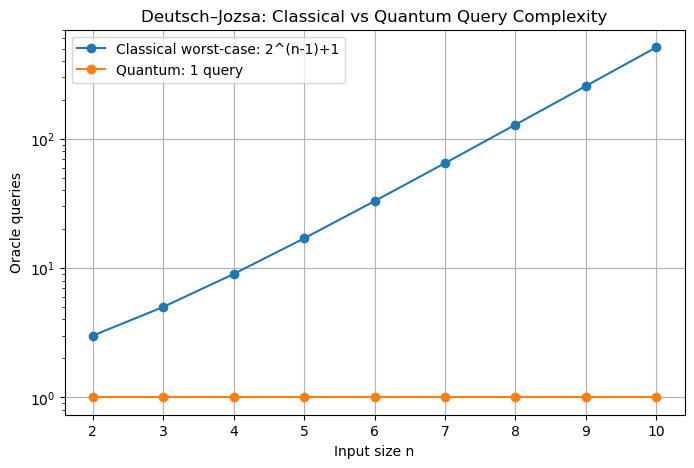

n=2: classical=3, quantum=1
n=3: classical=5, quantum=1
n=4: classical=9, quantum=1
n=5: classical=17, quantum=1
n=6: classical=33, quantum=1
n=7: classical=65, quantum=1
n=8: classical=129, quantum=1
n=9: classical=257, quantum=1
n=10: classical=513, quantum=1


In [2]:
n_values=np.arange(2,11)
classical=2**(n_values-1)+1
quantum=np.ones_like(n_values)
plt.figure(figsize=(8,5))
plt.plot(n_values,classical,marker="o",label="Classical worst-case: 2^(n-1)+1")
plt.plot(n_values,quantum,marker="o",label="Quantum: 1 query")
plt.xlabel("Input size n")
plt.ylabel("Oracle queries")
plt.title("Deutsch–Jozsa: Classical vs Quantum Query Complexity")
plt.yscale("log")
plt.grid()
plt.legend()
plt.show()
for n,c,q in zip(n_values,classical,quantum): print(f"n={n}: classical={c}, quantum={q}")